In [1]:
import numpy as np
import pandas as pd
from pathlib import Path



import matplotlib.pyplot as plt

import Functions

In [2]:
input_path = Functions.get_input_path() / 'App' / 'Data' / 'Ground_Campaign' / 'Flevoland_data'

weather_path = input_path / 'Data_corn_field' / 'Weather_data'
moisture_path = input_path / 'Data_corn_field' / 'SM_data'
parcelas_path = input_path / 'Data_25_fields'

path: /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA


Flevoland_data/Data_corn_field/Weather_data/Hobo_Dronten_corn_sept_20.csv

In [3]:
archivos = list(weather_path.glob('Hobo*.csv'))

df_temp = pd.read_csv(archivos[0], header=1, na_values='N/A')

display(df_temp)

,#,"Date Time, GMT+02:00","Temp, °C (LGR S/N: 1159679, SEN S/N: 9690816, LBL: air Temperature)","RH, % (LGR S/N: 1159679, SEN S/N: 9690816, LBL: RH)","DewPt, °C (LGR S/N: 1159679, SEN S/N: 9690816)"
0,1,24/05/17 03:45 PM,20.722,59.0,12.4
1,2,24/05/17 04:00 PM,19.960,65.4,13.3
2,3,24/05/17 04:15 PM,20.150,63.0,12.9
3,4,24/05/17 04:30 PM,19.651,60.8,11.9
4,5,24/05/17 04:45 PM,19.032,62.4,11.7
...,...,...,...,...,...
11400,11401,20/09/17 09:45 AM,12.389,98.7,12.2
11401,11402,20/09/17 10:00 AM,12.413,98.6,12.2
11402,11403,20/09/17 10:15 AM,12.582,98.5,12.4
11403,11404,20/09/17 10:30 AM,12.582,98.2,12.3


In [4]:
col_name = df_temp.columns[1]

# 2. Converti e sovrascrivi l'intera colonna
df_temp[col_name] = pd.to_datetime(
    df_temp[col_name], 
    format="%d/%m/%y %I:%M %p", 
    errors='coerce'
)

df_temp_clean = df_temp.drop(df_temp.columns[0], axis=1)
#display(df_temp_clean)

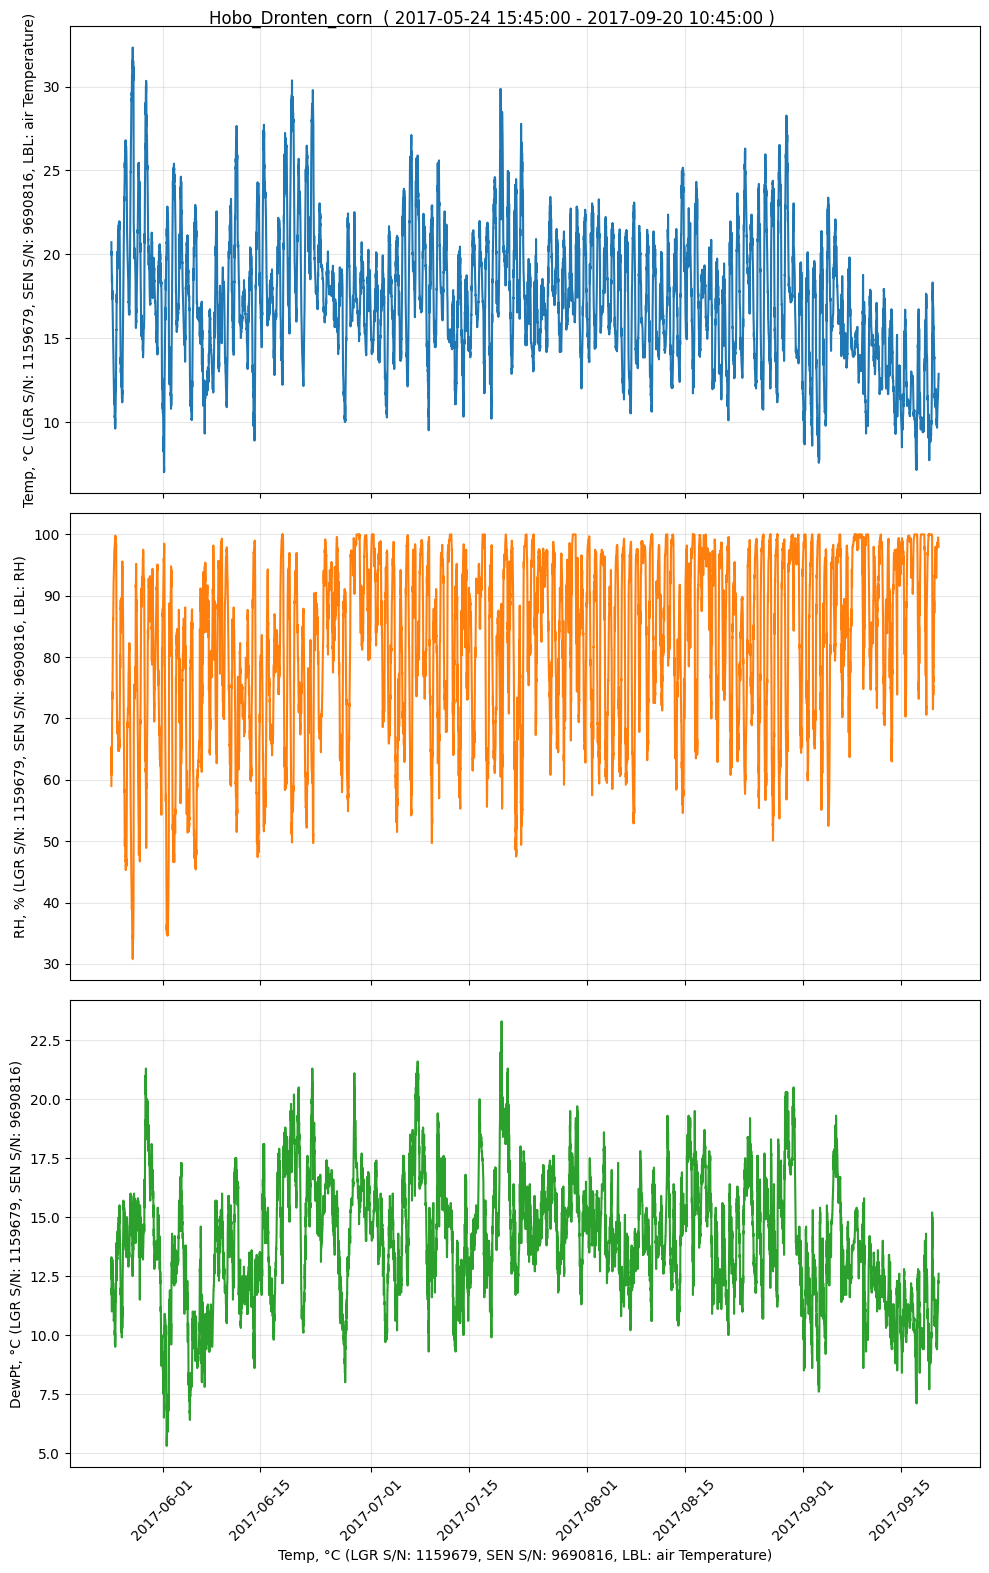

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 16), sharex=True)
plt.suptitle(f'Hobo_Dronten_corn  ( {df_temp_clean.iloc[0,0]} - {df_temp_clean.iloc[-1,0]} ) ')

# Lista degli indici delle colonne che vuoi plottare
colonne_y = [1, 2, 3]
data_x = df_temp_clean.iloc[:, 0]

for i, col_idx in enumerate(colonne_y):
    axes[i].plot(data_x, df_temp_clean.iloc[:, col_idx], color=f'C{i}') # C0, C1, C2 sono colori standard
    axes[i].set_ylabel(df_temp_clean.columns[col_idx])
    axes[i].grid(True, alpha=0.3)

plt.xlabel(df_temp_clean.columns[1])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Flevoland_data/Data_corn_field/Weather_data/EM27023 20sep17-1055_all_data.csv

In [6]:
archivos = list(weather_path.glob('*all_data*.csv'))
print(archivos)

df_EM27023 = pd.read_csv(archivos[0], header=2 , na_values='N/A', encoding='latin3')

display(df_EM27023)


[PosixPath('/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Data/Ground_Campaign/Flevoland_data/Data_corn_field/Weather_data/EM27023 20sep17-1055_all_data.csv')]


,Measurement Time,mm Precip,Solar W/m²,m/s Wind,m/s Gusts,° Direction,None,None.1
0,24-5-2017 15:41,0.0,809.3,2.6,2.6,302,NaN,NaN
1,24-5-2017 15:42,0.0,899.0,3.8,3.8,297,NaN,NaN
2,24-5-2017 15:43,0.0,664.7,2.3,2.3,333,NaN,NaN
3,24-5-2017 15:44,0.0,752.6,4.1,4.1,292,NaN,NaN
4,24-5-2017 15:45,0.0,889.9,4.4,4.4,306,NaN,NaN
...,...,...,...,...,...,...,...,...
11440,20-9-2017 9:45,0.0,86.1,0.7,1.4,193,NaN,NaN
11441,20-9-2017 10:00,0.0,75.1,1.4,1.9,192,NaN,NaN
11442,20-9-2017 10:15,0.0,106.2,2.0,2.8,193,NaN,NaN
11443,20-9-2017 10:30,0.0,104.4,2.4,3.1,190,NaN,NaN


In [7]:
df_EM27023['Measurement Time'] = pd.to_datetime(
    df_EM27023['Measurement Time'], 
    format="%d-%m-%Y %H:%M", 
    errors='coerce'
)
df_EM27023.set_index('Measurement Time', inplace=True)
display(df_EM27023)

,mm Precip,Solar W/m²,m/s Wind,m/s Gusts,° Direction,None,None.1
Measurement Time,,,,,,,
2017-05-24 15:41:00,0.0,809.3,2.6,2.6,302,NaN,NaN
2017-05-24 15:42:00,0.0,899.0,3.8,3.8,297,NaN,NaN
2017-05-24 15:43:00,0.0,664.7,2.3,2.3,333,NaN,NaN
2017-05-24 15:44:00,0.0,752.6,4.1,4.1,292,NaN,NaN
2017-05-24 15:45:00,0.0,889.9,4.4,4.4,306,NaN,NaN
...,...,...,...,...,...,...,...
2017-09-20 09:45:00,0.0,86.1,0.7,1.4,193,NaN,NaN
2017-09-20 10:00:00,0.0,75.1,1.4,1.9,192,NaN,NaN
2017-09-20 10:15:00,0.0,106.2,2.0,2.8,193,NaN,NaN


In [11]:
df_EM27023_clean = df_EM27023.iloc[:,0:5]

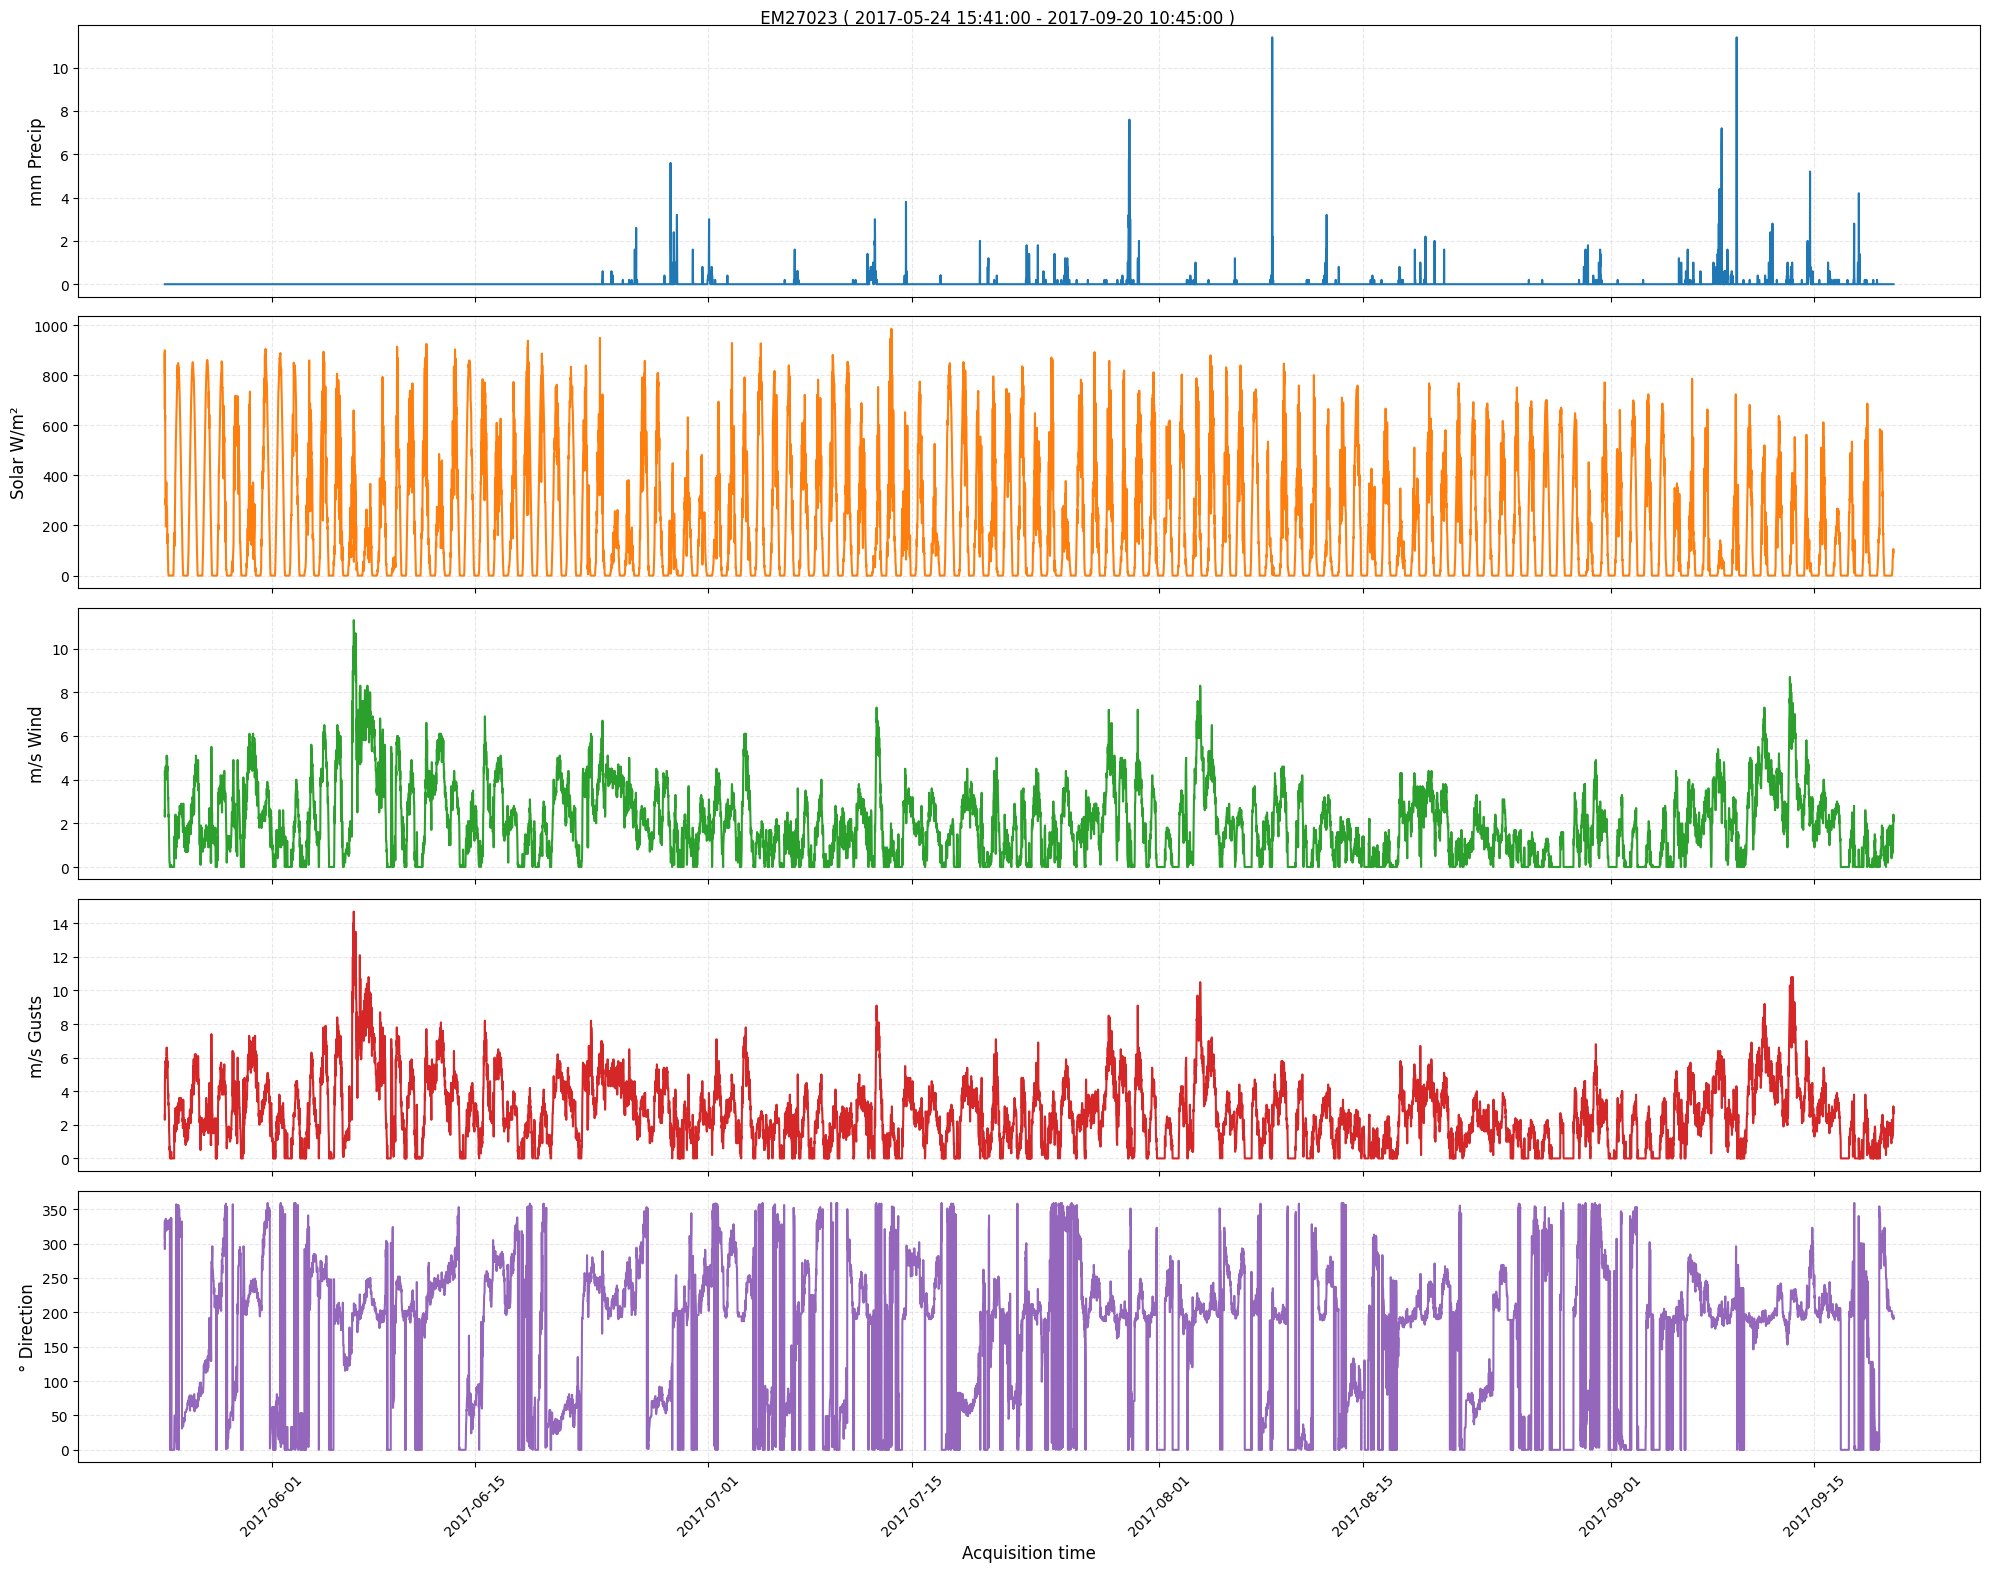

In [13]:
fig, axes = plt.subplots(5, 1, figsize=(20, 16), sharex=True)
data_x = df_EM27023_clean.index
plt.suptitle(f' EM27023 ( {data_x[0]} - {data_x[-1]} )' )

# Lista degli indici delle colonne che vuoi plottare
colonne_y = [0,1,2,3,4]
data_x = df_EM27023_clean.index

for i, col_idx in enumerate(colonne_y):
    # Plottiamo i dati
    axes[i].plot(data_x, df_EM27023_clean.iloc[:, col_idx], color=f'C{i}', linewidth=1.5)
    
    # Impostiamo il nome della colonna come etichetta Y
    nome_colonna = df_EM27023_clean.columns[col_idx]
    axes[i].set_ylabel(nome_colonna, fontsize=12)
    axes[i].grid(True, alpha=0.3, linestyle='--')

plt.xlabel('Acquisition time', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Unido Temperaturas ( df_temp_clean ) con condiciones atmosfericas (df_EM27023_clean)

In [ ]:
df_unito = pd.merge(df_temp_clean, df_EM27023_clean, left_on=df_temp_clean.columns[0], right_on=df_EM27023_clean.columns[0])
df_unito.drop(columns='Measurement Time', inplace=True)
display(df_unito)

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(20, 16), sharex=True)
plt.suptitle(f' df_merged ( {df_unito.iloc[0,0]} - {df_unito.iloc[-1,0]} )')

# Lista degli indici delle colonne che vuoi plottare
colonne_y = [1,2, 4, 5]
data_x = df_unito.iloc[:, 0]

for i, col_idx in enumerate(colonne_y):
    axes[i].plot(data_x, df_unito.iloc[:, col_idx], color=f'C{i}') # C0, C1, C2 sono colori standard
    axes[i].set_ylabel(df_unito.columns[col_idx])
    axes[i].grid(True, alpha=0.3)

plt.xlabel(df_unito.columns[1])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

MOISTURE
Flevoland_data/Data_corn_field/SM_data/M40529 20sep17-1127_all_data.csv

In [ ]:
archivos = list(moisture_path.glob('*all_data*.csv'))

df_EM40529 = pd.read_csv(archivos[0], header=1, na_values='#N/A')

display(df_EM40529)

In [ ]:
col_name = df_EM27023.columns[0]


df_EM40529[col_name] = pd.to_datetime(
    df_EM40529[col_name], 
    format="%d-%m-%Y %H:%M", 
    errors='coerce' # Se una riga è corrotta, mette NaT invece di crashare
)

display(df_EM40529)

df_EM40529_clean = df_EM40529.dropna(how='all', subset=df_EM40529.columns[1:5])
display(df_EM40529_clean)

In [ ]:
cols_to_fix = df_EM40529_clean.columns[1:]

# Applica la conversione a tutto il blocco e riassegna
df_EM40529_clean[cols_to_fix] = df_EM40529_clean[cols_to_fix].apply(pd.to_numeric, errors='coerce')

display(df_EM40529_clean.dtypes) #display(df_EM40529_clean)

In [ ]:
fig, ax = plt.subplots(figsize=(15, 8))

# Titolo dinamico
plt.suptitle(f'SOIL MOISTURE df_EM40529 ({df_EM40529_clean.iloc[1,0]} - {df_EM40529_clean.iloc[-1,0]})')

# Definiamo le colonne e l'asse X
colonne_y = [1, 2, 4, 5]
data_x = df_EM40529_clean.iloc[1:, 0]

# Ciclo unico su un solo asse (ax)
for i, col_idx in enumerate(colonne_y):
    ax.plot(data_x, 
            df_EM40529_clean.iloc[1:, col_idx], 
            label=df_EM40529_clean.columns[col_idx], 
            linewidth=1.5)

# Personalizzazione asse unico
ax.set_ylabel(df_EM40529_clean.iloc[0,1])
ax.set_xlabel(df_EM40529_clean.columns[0])
ax.grid(True, alpha=0.3)

# Aggiungiamo la legenda per distinguere le 5 linee
ax.legend(loc='best', fontsize='small', ncol=2) # ncol=2 per non occupare troppa altezza

# Rotazione date e layout
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

PARCELAS

averagie soil moisture:     fields_dict[Path(file).stem] = pd.read_excel(file, header=0)
Phenology_stages:            fields_dict[Path(file).stem] = pd.read_excel(file, header=0)
Soil_Roughness              


In [ ]:
def handle_ranges(value):
    if isinstance(value, str) and '-' in value:
        try:
            # Split "59-60" into [59, 60], convert to float, and average them
            parts = [float(x) for x in value.split('-')]
            #print(f'trovato {parts}')
            return float(sum(parts) / len(parts))
        except ValueError:
            return None # If it's something like "Date-Value", return None
    return value

In [ ]:
archivos = list(parcelas_path.glob('*.xlsx'))

print(archivos)
fields_dict = {}

for file in archivos:

    name = Path(file).stem

    if name == 'Averaged_crop_height':
        df = pd.read_excel(file, header=0)
        
        df.dropna(subset=['crop type'], inplace=True)

        df = df.map(handle_ranges)
        
        data_cols = df.columns[3:]
        
        # Applichiamo pd.to_numeric: trasforma tutto in float. 
        # Se qualcosa è rimasto testo, diventa NaN (evitando crash)
        df[data_cols] = df[data_cols].apply(pd.to_numeric, errors='coerce')

        # 5. Salvataggio nel dizionario
        fields_dict[name] = df
        
        df.to_parquet(f'/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/{name}.parquet')

        print(f"File '{name}' cleaned ( converted {len(df)} cells)")


print(df)

This other file (rainfall_total.parquet) icontains data of the all year

In [ ]:
archivos = list(weather_path.glob('measurements.csv'))
print(archivos)

df_EM27023 = pd.read_csv(archivos[0], header=0 , na_values='N/A', encoding='latin3')

#display(df_EM27023)

cols_to_keep = [c for c in df_EM27023.columns if c == 'end' or c.endswith('_v')]
df_EM27023_clean = df_EM27023[cols_to_keep]
display(df_EM27023_clean.iloc[:,0])
# 1. Convertiamo in datetime (gestendo il fuso orario ISO8601)
# Usiamo errors='coerce' per evitare blocchi se ci sono dati sporchi
df_EM27023_clean['end'] = pd.to_datetime(df_EM27023_clean['end'], utc=True)
# 2. Estraiamo solo la data (senza ore/minuti)
df_EM27023_clean['end'] = df_EM27023_clean['end'].dt.date

# 3. Rinominiamo le colonne per chiarezza
# Sostituisci 'pioggia_mm' con il nome reale della tua colonna dati
df_EM27023_clean.columns = ['date', 'prec_mm']

# 4. (Opzionale) Impostiamo la data come indice
df_EM27023_clean.set_index('date', inplace=True)


print(df_EM27023_clean.iloc[1])
df_EM27023_clean.to_parquet('/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/rainfall_total.parquet')

In [ ]:
mask = fields_dict['Average_Soil_moisture']['crop type'] == 'Sugarbeet'
df_sugarbeet_numeric = fields_dict['Average_Soil_moisture'].loc[mask, fields_dict['Average_Soil_moisture'].columns[2:]]
media_temporale = df_sugarbeet_numeric.mean(axis=0)

display(fields_dict['Average_Soil_moisture'][mask])

In [ ]:
unique_crops = set()

for keys in fields_dict:
    crops_in_df = fields_dict[keys]['crop type'].unique()
    unique_crops.update(crops_in_df) 

crops_type_dict = { k: {} for k in unique_crops}

print(unique_crops)
print(fields_dict.keys())

Promedio por tipo de arbol en cada caracteristica